In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import os

### Text Property Scores

Binary attributes:
- toxicity: 0/1
- formality: 0/1

Continuous attributes:
- politeness: 1.0-5.0
- intimacy: -1.0-1.0 
- text_certainty: 1.0-6.0

In [84]:
# cont_var = ['text_politeness', 'text_certainty', 'text_intimacy']
# clip_ranges = [(1.0, 5.0), (2.5, 6.5), (-1.0, 1.0)]

# sns.set_style("white",  {"grid.color": ".8"})

# fig, axes = plt.subplots(1, 3, figsize=(15, 5))   

# for ax, var, clip_range in zip(axes, cont_var, clip_ranges):
#     sns.kdeplot(data=data, x=var, fill=True, palette="crest", alpha=0, clip=clip_range, ax=ax)
#     ax.set_title(f'Probability Density of {var}')
#     ax.set_xlim(clip_range)

# plt.tight_layout()
# plt.show()

## Continuous attributes

In [139]:
def plot_attributes_overlap(data, att_lst, init_scales, x_label, fig_name, smooth_adjust):
    sns.set_style("whitegrid",  {"grid.color": ".8"})

    normalized_data = pd.DataFrame()
    for var, (target_min, target_max) in zip(att_lst, init_scales):
        # normalize the initial scale to (0,1)
        normalized_data[var] = ((data[var] - target_min) / (target_max - target_min))

    plt.figure(figsize=(9, 6))  
    for var in att_lst:
        sns.kdeplot(data=normalized_data, x=var, fill=True, alpha=0, label=var, bw_adjust=smooth_adjust)
     
    plt.ylabel('Density', fontsize=14)
    plt.xlabel(x_label, fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12)
    plt.savefig(fig_name, bbox_inches='tight')
    plt.show()

In [ ]:
data = pd.read_csv("/shared/3/projects/mingqian/per-my-previous-email/final-data/en.2009-all.tsv", sep='\t')

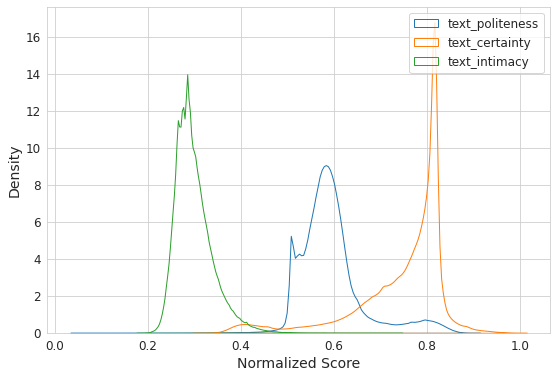

In [140]:
sns.set_style("whitegrid",  {"grid.color": ".8"})

cont_var = ['text_politeness', 'text_certainty', 'text_intimacy']
ranges = [(1.0, 5.0), (1.0, 6.0), (-1.0, 1.0)]

plot_attributes_overlap(data, cont_var, ranges, 
                        'Normalized Score', 
                        "../visualizations/text_polite_certain_intimate.pdf", 1)

In [65]:
data["nchar_body"].quantile([0.25, 0.50, 0.97])

0.25     120.0
0.50     261.0
0.97    2042.0
Name: nchar_body, dtype: float64

In [63]:
data["nchar_code"].quantile([0.25, 0.50, 0.97])

0.25      0.0
0.50      0.0
0.97    330.0
Name: nchar_code, dtype: float64

In [62]:
data["nchar_quot"].quantile([0.25, 0.50, 0.97])

0.25       0.0
0.50      59.0
0.97    3605.0
Name: nchar_quot, dtype: float64

In [81]:
def plot_attributes_separate(data, att_lst, clip_ranges, fig_name):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))   

    for ax, var, clip_range in zip(axes, att_lst, clip_ranges):
        sns.kdeplot(data=data, x=var, fill=True, palette="crest", alpha=0, clip=clip_range, ax=ax)

    plt.tight_layout()
    plt.savefig(fig_name, bbox_inches='tight')
    plt.show()

<ipython-input-81-2a69761908de>:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(data=data, x=var, fill=True, palette="crest", alpha=0, clip=clip_range, ax=ax)
<ipython-input-81-2a69761908de>:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(data=data, x=var, fill=True, palette="crest", alpha=0, clip=clip_range, ax=ax)
<ipython-input-81-2a69761908de>:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(data=data, x=var, fill=True, palette="crest", alpha=0, clip=clip_range, ax=ax)
<ipython-input-81-2a69761908de>:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(data=data, x=var, fill=True, palette="crest", alpha=0, clip=clip_range, ax=ax)


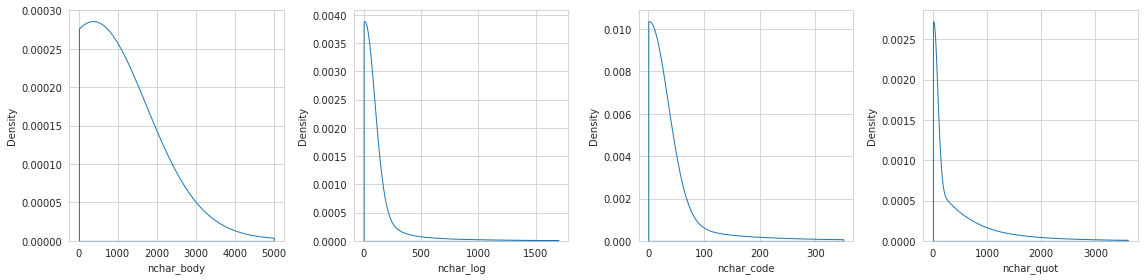

In [83]:
cont_var = ["nchar_body", "nchar_log", "nchar_code", "nchar_quot"]
clip_ranges = [(0, 5000), (0, 1700), (0, 350), (0, 3600)]

plot_attributes_separate(data, cont_var, clip_ranges, "../visualizations/kde_nchar.pdf")

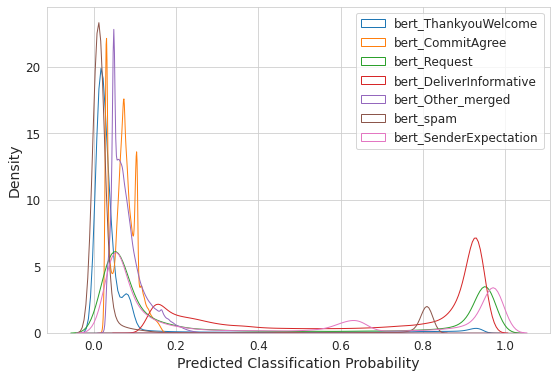

In [141]:
cont_var = ['bert_ThankyouWelcome','bert_CommitAgree',
            'bert_Request','bert_DeliverInformative',
            'bert_Other_merged','bert_spam',
            'bert_SenderExpectation']
ranges = [(0,1)]*len(cont_var)

plot_attributes_overlap(data, cont_var, ranges, 
                        'Predicted Classification Probability',
                        "../visualizations/kde_bert_results.pdf", 1.5)

## Binary attributes

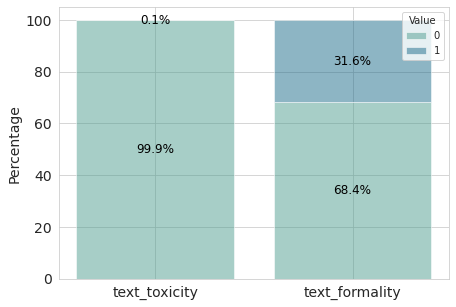

In [129]:
percentages = []
attributes = ['text_toxicity', 'text_formality']
for attr in attributes:
    total = len(data[attr])
    count_1 = data[attr].sum()
    count_0 = total - count_1
    percentages.append({
        'Attribute': attr,
        'Percentage': count_0 / total * 100,
        'Value': '0'
    })
    percentages.append({
        'Attribute': attr,
        'Percentage': count_1 / total * 100,
        'Value': '1'
    })

# Convert to DataFrame
percentage_df = pd.DataFrame(percentages)

# Create the stacked bar plot
fig, ax = plt.subplots(figsize=(7, 5))

palette = sns.color_palette("crest", n_colors=2)

bottom = pd.Series([0, 0])
for index, value in enumerate(['0', '1']):
    df_subset = percentage_df[percentage_df['Value'] == value]
    ax.bar(
        df_subset['Attribute'],
        df_subset['Percentage'],
        bottom=bottom,
        label=value,
        alpha=0.5,
        color=palette[index]
    )
    bottom += df_subset['Percentage'].reset_index(drop=True)

    # Add annotations
    for i, (attr, pct) in enumerate(zip(df_subset['Attribute'], df_subset['Percentage'])):
        ax.text(
            attr,
            bottom[i] - pct / 2,
            f'{pct:.1f}%',
            ha='center',
            va='center',
            color='black',
            fontsize=12
        )

ax.tick_params(labelsize=14)   
plt.ylabel('Percentage', fontsize=14)
plt.legend(title='Value', fontsize=10)
plt.savefig("../visualizations/kde_text_binary.pdf", bbox_inches='tight')
plt.show()

In [89]:
data["text_toxicity"].value_counts()

text_toxicity
0.0    10013030
1.0       14861
Name: count, dtype: int64

In [145]:
net_dir = "/shared/3/projects/mingqian/per-my-previous-email/network-properties"

files = [os.path.join(net_dir, file) for file in os.listdir(net_dir)]
dfs = []

# Loop through the files and read each one into a DataFrame
for file in files:
    df = pd.read_csv(file, sep='\t')  
    dfs.append(df)

# Concatenate all DataFrames in the list into a single DataFrame
net_all = pd.concat(dfs, ignore_index=True)

# Save the combined DataFrame to a new TSV file
output_file = "/shared/3/projects/mingqian/per-my-previous-email/en.2009-all-net.tsv" 
net_all.to_csv(output_file, sep='\t', index=False)

In [7]:
net_all = pd.read_csv("/shared/3/projects/mingqian/per-my-previous-email/en.2009-all-net.tsv", sep='\t')

In [10]:
net_all.columns

Index(['from', 'net_indegree', 'net_outdegree', 'net_betweenness', 'net_hub',
       'net_authority', 'net_pagerank', 'net_clustering', 'net_reciprocity',
       'net_cc', 'net_num_cc'],
      dtype='object')

In [53]:
net_all["net_pagerank"].quantile([0.25, 0.50, 0.97])

0.25    0.000004
0.50    0.000004
0.97    0.000014
Name: net_pagerank, dtype: float64

In [31]:
net_all["net_authority"].quantile([0.25, 0.50, 0.97])

0.25   -4.803563e-19
0.50    9.116449e-19
0.97    4.329226e-07
Name: net_authority, dtype: float64

In [8]:
net_all["net_hub"].quantile([0.25, 0.50, 0.97])

0.25    2.622769e-17
0.50    1.306960e-11
0.97    7.494360e-05
Name: net_hub, dtype: float64

<ipython-input-55-0362f8fa8385>:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(data=net_all, x=var, fill=True, palette="crest", alpha=0, clip=clip_range, ax=ax)
<ipython-input-55-0362f8fa8385>:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(data=net_all, x=var, fill=True, palette="crest", alpha=0, clip=clip_range, ax=ax)
<ipython-input-55-0362f8fa8385>:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(data=net_all, x=var, fill=True, palette="crest", alpha=0, clip=clip_range, ax=ax)


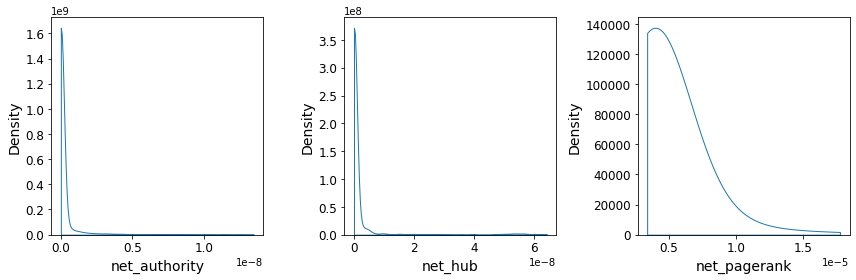

In [55]:
normalized_data = pd.DataFrame()
att_lst = ['net_authority', 'net_hub', 'net_pagerank']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))   

for ax, var in zip(axes, att_lst):
    clip_range = (net_all[var].quantile(.02), net_all[var].quantile(.98))
    sns.kdeplot(data=net_all, x=var, fill=True, palette="crest", alpha=0, clip=clip_range, ax=ax)
 
    ax.set_ylabel('Density', fontsize=14)
    ax.set_xlabel(var, fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    
plt.tight_layout()
plt.savefig("../visualizations/kde_user_network_scores.pdf", bbox_inches='tight')

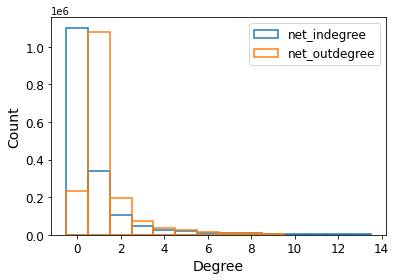

In [30]:
data = net_all
cols = ['net_indegree', 'net_outdegree']
plt.figure(figsize=(6, 4))  
for var in cols:
    sns.histplot(data=data[data[var].between(data[var].quantile(.02), data[var].quantile(.98))], x=var, label=var, fill=False,discrete=True)

# plt.title("Indegree & Outdegree of Network nodes")
plt.ylabel('Count', fontsize=14)
plt.xlabel('Degree', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.savefig("../visualizations/bar_inout_deg.pdf", bbox_inches='tight')
plt.show()